# Global GDP Explorer
## Data Analysis & Exploratory Data Analysis

**Portfolio Analysis Notebook**

This notebook explores global GDP data across countries and years, evaluates data quality, analyzes trends and growth, and prepares analytical outputs for the interactive Streamlit dashboard.

In [1]:
# Import the libraries used throughout the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set the default visualization style
# Display pandas output more clearly
pd.set_option("display.max_columns", None)

## 1. Load Dataset

In [2]:
# Locate the dataset from the notebook or project root
possible_paths = [
    Path("../data/gdp_data.csv"),
    Path("data/gdp_data.csv"),
    Path("gdp_data.csv")
]

DATA_PATH = next(
    (path for path in possible_paths if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError("gdp_data.csv was not found in the expected project locations.")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset path:", DATA_PATH)

Dataset loaded successfully.
Dataset path: ../data/gdp_data.csv


## 2. Dataset Overview

In [3]:
# Inspect the dataset structure and sample records
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

display(df.head())

Dataset Shape: (266, 68)

Column Names:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', 'Unnamed: 67']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,Unnamed: 67
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.055866e+08,4.877095e+08,5.966480e+08,6.955307e+08,7.648045e+08,8.720670e+08,9.586592e+08,1.083240e+09,1.245810e+09,1.320670e+09,1.379888e+09,1.531844e+09,1.665363e+09,1.722905e+09,1.873453e+09,1.896457e+09,1.961844e+09,2.044112e+09,2.254831e+09,2.360017e+09,2.469783e+09,2.677641e+09,2.843025e+09,2.553793e+09,2.453597e+09,2.637859e+09,2.615208e+09,2.727850e+09,2.790850e+09,2.962907e+09,2.983635e+09,3.092429e+09,3.276184e+09,3.395799e+09,2.558906e+09,3.103184e+09,3.544708e+09,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,1.847810e+10,1.936631e+10,2.050647e+10,2.224273e+10,2.429433e+10,2.661956e+10,2.873279e+10,3.159296e+10,3.421651e+10,3.849869e+10,4.193891e+10,4.592017e+10,4.944074e+10,6.493383e+10,7.988815e+10,8.495509e+10,8.505030e+10,9.456692e+10,1.056234e+11,1.256564e+11,1.664751e+11,1.736735e+11,1.641141e+11,1.751087e+11,1.627521e+11,1.357955e+11,1.533687e+11,1.865947e+11,2.056359e+11,2.185774e+11,2.546735e+11,2.756220e+11,2.402106e+11,2.383531e+11,2.411580e+11,2.708140e+11,2.689929e+11,2.840654e+11,2.672867e+11,2.636742e+11,2.854038e+11,2.602186e+11,2.671421e+11,3.549074e+11,4.413596e+11,5.149271e+11,5.786333e+11,6.640994e+11,7.118005e+11,7.235125e+11,8.670409e+11,9.716675e+11,9.799969e+11,9.863429e+11,1.006992e+12,9.325135e+11,8.900514e+11,1.028394e+12,1.012521e+12,1.006191e+12,9.288802e+11,1.086531e+12,1.185138e+12,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,1.400000e+09,1.673333e+09,1.373333e+09,1.408889e+09,1.748887e+09,1.831109e+09,1.595555e+09,1.733333e+09,2.155555e+09,2.366667e+09,2.555556e+09,2.953333e+09,3.300000e+09,3.697940e+09,3.641723e+09,3.478788e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.825701e+09,4.520947e+09,5.224897e+09,6.203256e+09,6.971758e+09,9.747886e+09,1.010930e+10,1.241615e+10,1.585667e+10,1.780510e+10,1.990733e+10,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426650e+10,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.041165e+10,1.113592e+10,1.195171e+10,1.268581e+10,1.384900e+10,1.487476e+10,1.584558e+10,1.442849e+10,1.488050e+10,1.688228e+10,2.350496e+10,2.084333e+10,2.526946e+10,3.184115e+10,4.421533e+10,5.144531e+10,6.212999e+10,6.531603e+10,7.120053e+10,8.862933e+10,1.120323e+11,2.110059e+11,1.871654e+11,1.381169e+11,1.142639e+11,1.165085e+11,1.075070e+11,1.102817e+11,1.089447e+11,1.017701e+11,1.218036e+11,1.279390e+11,1.225760e+11,1.279809e+11,1.331435e+11,2.056871e+11,2.612621e+11,2.743770e+11,2.949498e+11,1.372925e+11,1.401328e+11,1.475247e+11,1.765886e+11,2.044550e+11,2.534537e+11,3.100707e+11,3.960770e+11,4.656273e+11,5.678534e+11,5.084925e+11,5.986075e+11,6.821761e+11,7.377395e+11,8.340970e+11,8.945050e+11,7.692632e+11,6.921149e+11,6.856303e+11,7.681582e+11,8.234056e+11,7.869624e+11,8.449275e+11,8.753937e+11,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.934074e+09,5.553824e+09,5.553824e+09,5.787824e+09,6.135166e+09,7.558613e+09,7.076794e+09,8.089279e+09,8.775116e+09,1.020792e+10,1.123628e+10,1.040119e+10,8.307827e+09,6.084689e+09,4.438321e+09,5.538749e+09,6.535435e+09,7.675413e+09,6.506381e+09,6.152923e+09,9.129595e+09,8.936079e+09,1.528559e+10,1.781270e+10,2.355206e+10,3.697090e+10,5.238103e+10,6.526642e+10,8.853866e+10,7.030720e+10,8.

In [4]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 68 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            126 non-null    float64
 5   1961            127 non-null    float64
 6   1962            128 non-null    float64
 7   1963            128 non-null    float64
 8   1964            128 non-null    float64
 9   1965            140 non-null    float64
 10  1966            143 non-null    float64
 11  1967            146 non-null    float64
 12  1968            151 non-null    float64
 13  1969            151 non-null    float64
 14  1970            160 non-null    float64
 15  1971            163 non-null    float64
 16  1972            163 non-null    float64
 17  1973            163 non-null    flo

In [5]:
# Generate descriptive statistics for the dataset
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country Name,266,266,Aruba,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country Code,266,266,ABW,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Indicator Name,266,1,GDP (current US$),266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Indicator Code,266,1,NY.GDP.MKTP.CD,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960,126.0,NaN,NaN,NaN,72953390357.841217,218674390875.446503,12012024.624651,515168342.411049,2661057725.65049,23980134963.738075,1381135479871.290039
...,...,...,...,...,...,...,...,...,...,...,...
2019,258.0,NaN,NaN,NaN,2817909742988.783691,9553275393363.521484,54123198.566291,10355162360.555901,60090991763.311501,541948969932.865234,87777403956321.09375
2020,257.0,NaN,NaN,NaN,2741617581853.61084,9323528176609.517578,51746594.314854,9754600000.0,53734526854.228897,547054174235.875977,85257737349905.5
2021,256.0,NaN,NaN,NaN,3169838033814.438477,10688680018756.824219,60196405.713839,10808725425.245274,65611769413.859299,650122751155.026245,97529676807424.796875
2022,243.0,NaN,NaN,NaN,3479221343207.75,11336193792943.673828,59065979.022768,14035732691.2948,75732311666.039001,891256064805.385986,101325686724630.0


## 3. Data Quality Assessment

In [6]:
# Check for duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 0


In [7]:
# Calculate the number of missing values in each column
missing_values = df.isnull().sum()

# Keep only columns that contain missing values
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

display(missing_values)

Unnamed: 67    266
1960           140
1961           139
1962           138
1964           138
              ... 
2015             8
2016             8
2013             7
2014             6
2011             6
Length: 64, dtype: int64

In [8]:
# Calculate the percentage of missing values in each column
missing_percentage = df.isnull().mean() * 100

# Keep only columns that contain missing values
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

display(missing_percentage)

Unnamed: 67    100.000000
1960            52.631579
1961            52.255639
1962            51.879699
1964            51.879699
                  ...    
2015             3.007519
2016             3.007519
2013             2.631579
2014             2.255639
2011             2.255639
Length: 64, dtype: float64

## 4. Prepare the Dataset

In [9]:
# Remove automatically generated empty columns, if present
empty_columns = [
    column for column in df.columns
    if str(column).startswith("Unnamed:")
]

df = df.drop(columns=empty_columns)

print("Removed columns:", empty_columns)

Removed columns: ['Unnamed: 67']


In [10]:
# Identify columns that represent years
year_columns = [
    column for column in df.columns
    if str(column).isdigit()
]

print("Number of year columns:", len(year_columns))
print("First year:", year_columns[0])
print("Last year:", year_columns[-1])

Number of year columns: 63
First year: 1960
Last year: 2022


In [11]:
# Count the number of unique countries and economies
number_of_countries = df["Country Code"].nunique()

print("Number of countries/economies:", number_of_countries)

Number of countries/economies: 266


In [12]:
# Convert the dataset from wide format to long format
gdp_df = df.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_columns,
    var_name="Year",
    value_name="GDP"
)

# Convert Year from string to integer
gdp_df["Year"] = pd.to_numeric(gdp_df["Year"])

display(gdp_df.head())

,Country Name,Country Code,Year,GDP
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,1.847810e+10
2,Afghanistan,AFG,1960,5.377778e+08
3,Africa Western and Central,AFW,1960,1.041165e+10
4,Angola,AGO,1960,NaN


In [13]:
# Check the transformed dataset
print("Transformed Dataset Shape:", gdp_df.shape)

print("\nData Types:")
print(gdp_df.dtypes)

Transformed Dataset Shape: (16758, 4)

Data Types:
Country Name     object
Country Code     object
Year              int64
GDP             float64
dtype: object


In [14]:
# Calculate missing GDP observations
missing_gdp = gdp_df["GDP"].isna().sum()
total_observations = len(gdp_df)
missing_gdp_percentage = missing_gdp / total_observations * 100

print("Total observations:", f"{total_observations:,}")
print("Missing GDP values:", f"{missing_gdp:,}")
print(f"Missing GDP percentage: {missing_gdp_percentage:.2f}%")

Total observations: 16,758
Missing GDP values: 3,558
Missing GDP percentage: 21.23%


## 5. Exploratory Data Analysis

In [15]:
# Generate descriptive statistics for GDP
gdp_df["GDP"].describe()

count    1.320000e+04
mean     1.224017e+12
std      5.455760e+12
min      8.824744e+06
25%      2.434996e+09
50%      1.786106e+10
75%      2.272244e+11
max      1.013257e+14
Name: GDP, dtype: float64

In [16]:
# Calculate GDP statistics for each year
year_summary = (
    gdp_df
    .groupby("Year")["GDP"]
    .agg(["count", "mean", "median", "sum"])
    .reset_index()
)

display(year_summary.head())

,Year,count,mean,median,sum
0,1960,126,7.295339e+10,2.661058e+09,9.192127e+12
1,1961,127,7.486095e+10,2.417629e+09,9.507341e+12
2,1962,128,7.866324e+10,2.319980e+09,1.006889e+13
3,1963,128,8.518005e+10,2.680117e+09,1.090305e+13
4,1964,128,9.404305e+10,2.853831e+09,1.203751e+13


In [17]:
# Calculate total global GDP for each year
global_gdp = (
    gdp_df
    .groupby("Year", as_index=False)["GDP"]
    .sum()
)

# Convert GDP to trillion USD
global_gdp["GDP Trillion"] = global_gdp["GDP"] / 1e12

display(global_gdp.head())

,Year,GDP,GDP Trillion
0,1960,9.192127e+12,9.192127
1,1961,9.507341e+12,9.507341
2,1962,1.006889e+13,10.068895
3,1963,1.090305e+13,10.903046
4,1964,1.203751e+13,12.037511


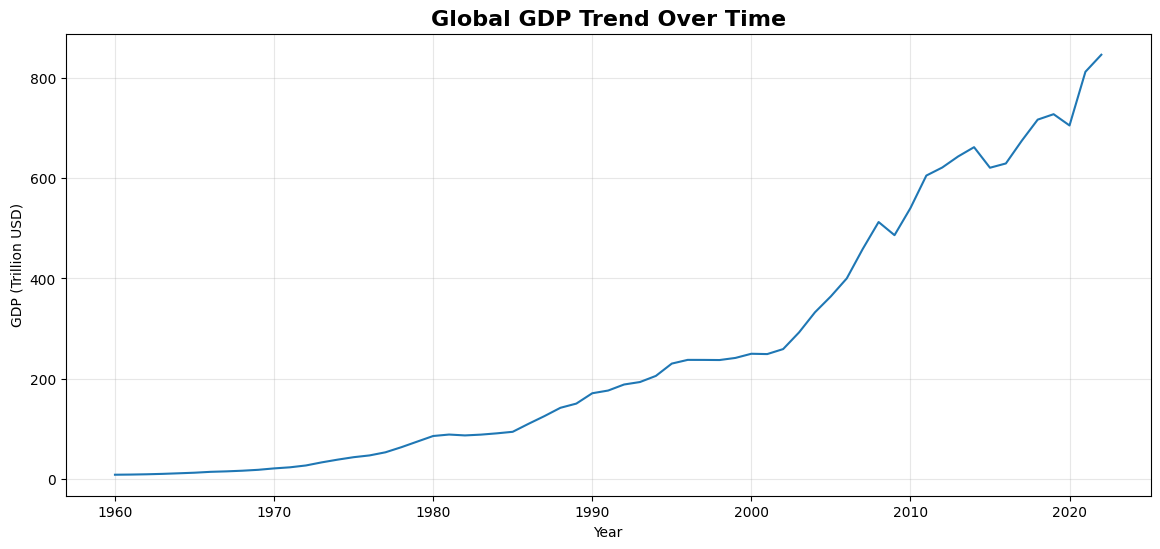

In [18]:
# Plot the global GDP trend over time
plt.figure(figsize=(14, 6))

plt.plot(
    global_gdp["Year"],
    global_gdp["GDP Trillion"]
)

plt.title("Global GDP Trend Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("GDP (Trillion USD)")
plt.grid(alpha=0.3)

plt.show()

In [19]:
# Calculate year-over-year global GDP growth
global_gdp["YoY Growth %"] = global_gdp["GDP"].pct_change() * 100

display(global_gdp.head())

,Year,GDP,GDP Trillion,YoY Growth %
0,1960,9.192127e+12,9.192127,NaN
1,1961,9.507341e+12,9.507341,3.429171
2,1962,1.006889e+13,10.068895,5.906531
3,1963,1.090305e+13,10.903046,8.284438
4,1964,1.203751e+13,12.037511,10.405024


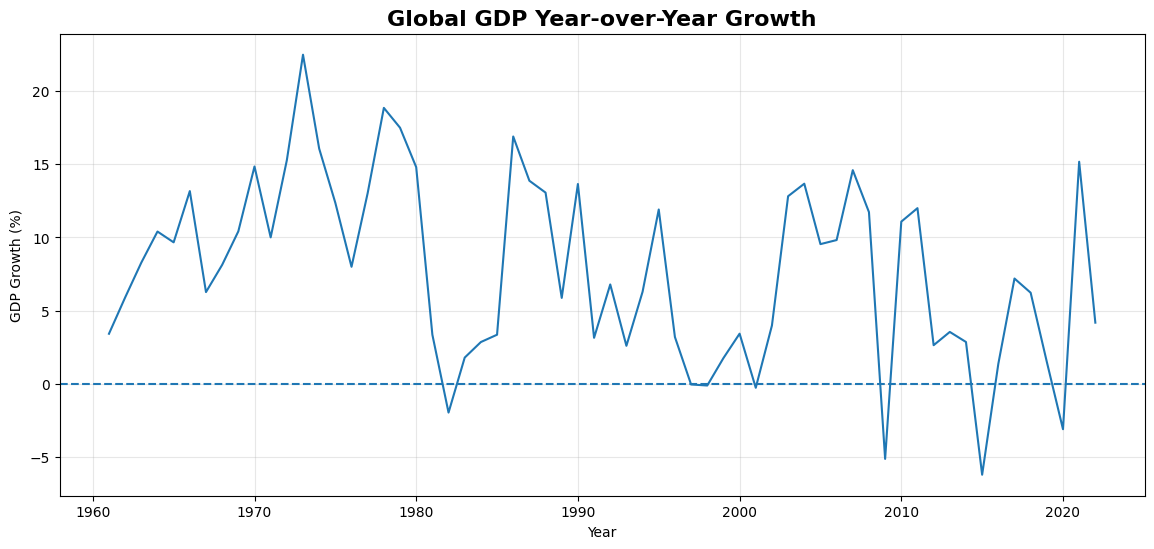

In [20]:
# Plot year-over-year global GDP growth
plt.figure(figsize=(14, 6))

plt.plot(
    global_gdp["Year"],
    global_gdp["YoY Growth %"]
)

plt.axhline(0, linestyle="--")
plt.title("Global GDP Year-over-Year Growth", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(alpha=0.3)

plt.show()

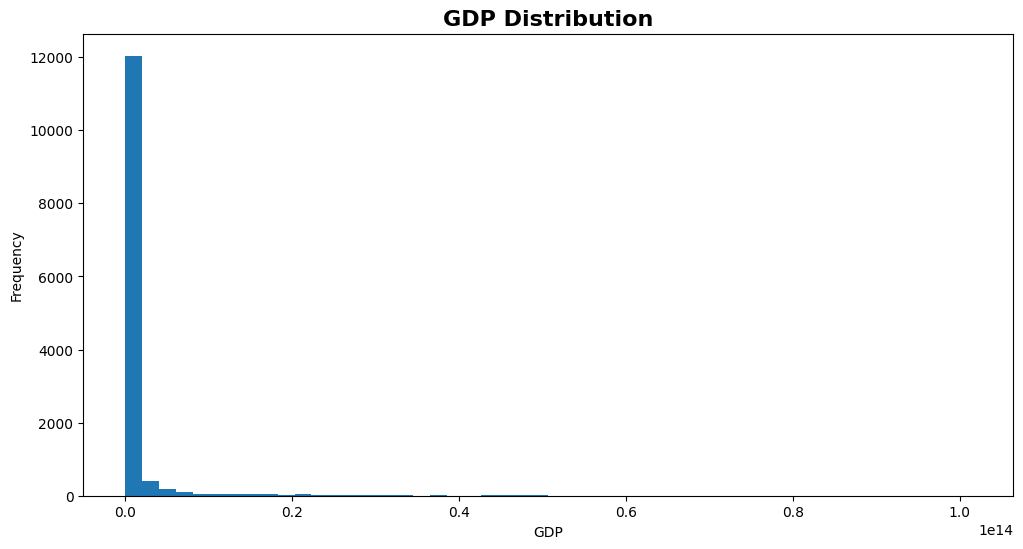

In [21]:
# Visualize the distribution of GDP values
plt.figure(figsize=(12, 6))

plt.hist(
    gdp_df["GDP"].dropna(),
    bins=50
)

plt.title("GDP Distribution", fontsize=16, fontweight="bold")
plt.xlabel("GDP")
plt.ylabel("Frequency")

plt.show()

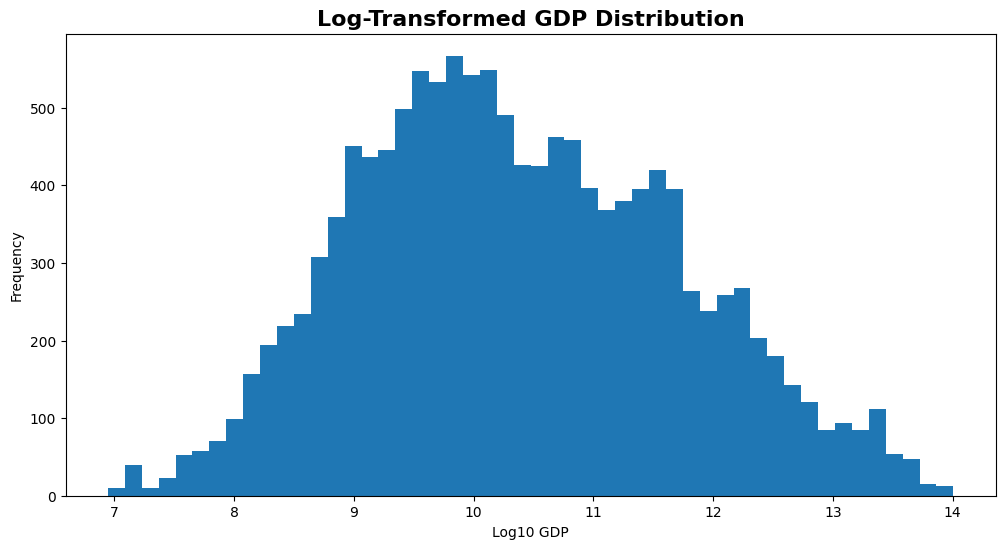

In [22]:
# Apply a logarithmic transformation to reduce the effect of extreme values
log_gdp = np.log10(gdp_df["GDP"].dropna())

plt.figure(figsize=(12, 6))

plt.hist(log_gdp, bins=50)

plt.title("Log-Transformed GDP Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Log10 GDP")
plt.ylabel("Frequency")

plt.show()

## 6. Latest-Year Analysis

In [23]:
# Get the latest available year
latest_year = int(gdp_df["Year"].max())

print("Latest available year:", latest_year)

Latest available year: 2022


In [24]:
# Filter GDP data for the latest available year
latest_gdp = (
    gdp_df[gdp_df["Year"] == latest_year]
    .dropna(subset=["GDP"])
    .sort_values("GDP", ascending=False)
)

display(latest_gdp.head(10))

,Country Name,Country Code,Year,GDP
16751,World,WLD,2022,1.013257e+14
16587,High income,HIC,2022,6.166747e+13
16673,OECD members,OED,2022,5.978785e+13
16690,Post-demographic dividend,PST,2022,5.666168e+13
16595,IDA & IBRD total,IBT,2022,4.057396e+13
16632,Low & middle income,LMY,2022,3.930979e+13
16648,Middle income,MIC,2022,3.878098e+13
16594,IBRD only,IBD,2022,3.775237e+13
16555,East Asia & Pacific,EAS,2022,3.068824e+13
16741,Upper middle income,UMC,2022,3.060946e+13


In [25]:
# Create the latest GDP ranking
latest_ranking = latest_gdp[
    ["Country Name", "Country Code", "GDP"]
].copy()

latest_ranking["Rank"] = range(1, len(latest_ranking) + 1)
latest_ranking["GDP Trillion"] = latest_ranking["GDP"] / 1e12

display(latest_ranking.head(20))

,Country Name,Country Code,GDP,Rank,GDP Trillion
16751,World,WLD,1.013257e+14,1,101.325687
16587,High income,HIC,6.166747e+13,2,61.667467
16673,OECD members,OED,5.978785e+13,3,59.787850
16690,Post-demographic dividend,PST,5.666168e+13,4,56.661681
16595,IDA & IBRD total,IBT,4.057396e+13,5,40.573962
16632,Low & middle income,LMY,3.930979e+13,6,39.309792
16648,Middle income,MIC,3.878098e+13,7,38.780980
16594,IBRD only,IBD,3.775237e+13,8,37.752366
16555,East Asia & Pacific,EAS,3.068824e+13,9,30.688236
16741,Upper middle income,UMC,3.060946e+13,10,30.609458


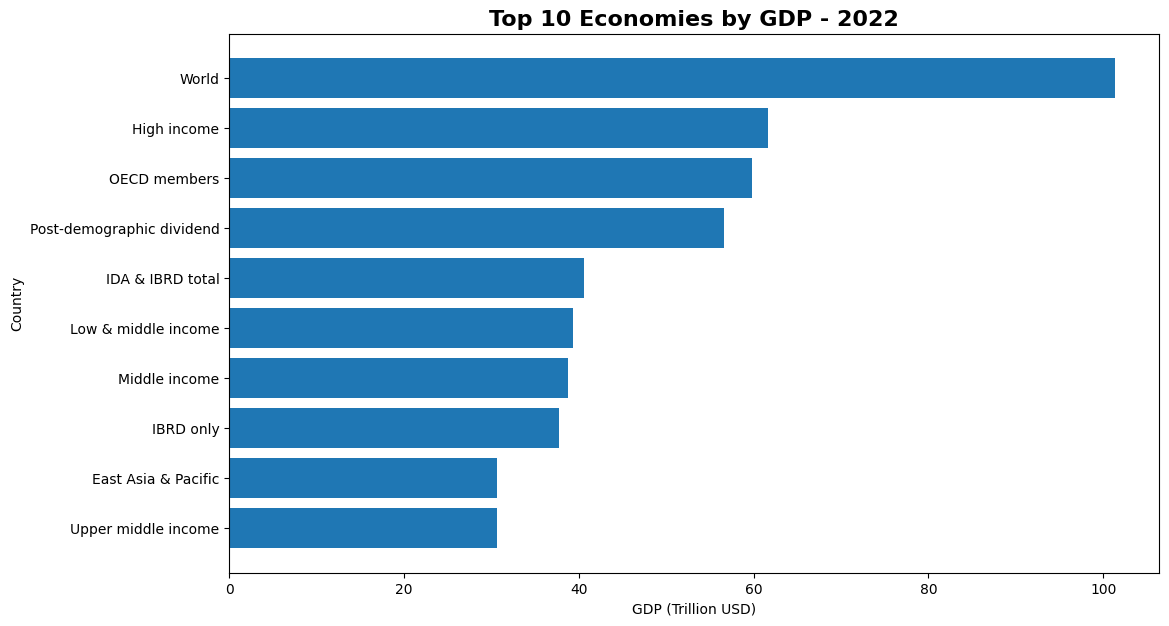

In [26]:
# Visualize the top 10 economies by GDP
top_10 = latest_ranking.head(10).sort_values("GDP Trillion")

plt.figure(figsize=(12, 7))

plt.barh(
    top_10["Country Name"],
    top_10["GDP Trillion"]
)

plt.title(f"Top 10 Economies by GDP - {latest_year}", fontsize=16, fontweight="bold")
plt.xlabel("GDP (Trillion USD)")
plt.ylabel("Country")

plt.show()

## 7. Country Comparison

In [27]:
# Select countries for detailed comparison
selected_countries = ["USA", "CHN", "DEU", "JPN", "GBR", "FRA"]

comparison_df = gdp_df[
    gdp_df["Country Code"].isin(selected_countries)
]

display(comparison_df.head())

,Country Name,Country Code,Year,GDP
40,China,CHN,1960,5.971625e+10
55,Germany,DEU,1960,NaN
77,France,FRA,1960,6.222548e+10
81,United Kingdom,GBR,1960,7.323397e+10
119,Japan,JPN,1960,4.430734e+10


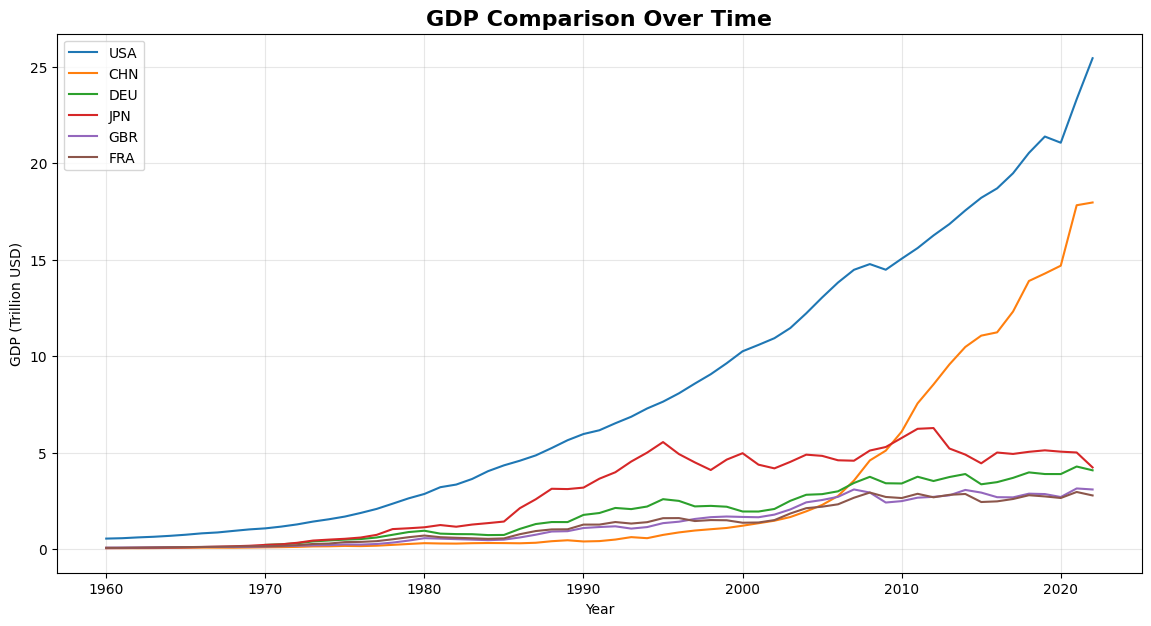

In [28]:
# Compare GDP trends for the selected countries
plt.figure(figsize=(14, 7))

for country in selected_countries:
    country_data = comparison_df[
        comparison_df["Country Code"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["GDP"] / 1e12,
        label=country
    )

plt.title("GDP Comparison Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("GDP (Trillion USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8. Growth Analysis

In [29]:
# Sort the data before calculating year-over-year growth
gdp_df = gdp_df.sort_values(["Country Code", "Year"]).copy()

# Calculate year-over-year GDP growth for each country
gdp_df["YoY Growth %"] = (
    gdp_df.groupby("Country Code")["GDP"].pct_change() * 100
)

display(gdp_df.head())

/tmp/ipykernel_898/4169689805.py:6: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  gdp_df.groupby("Country Code")["GDP"].pct_change() * 100


,Country Name,Country Code,Year,GDP,YoY Growth %
0,Aruba,ABW,1960,NaN,NaN
266,Aruba,ABW,1961,NaN,NaN
532,Aruba,ABW,1962,NaN,NaN
798,Aruba,ABW,1963,NaN,NaN
1064,Aruba,ABW,1964,NaN,NaN


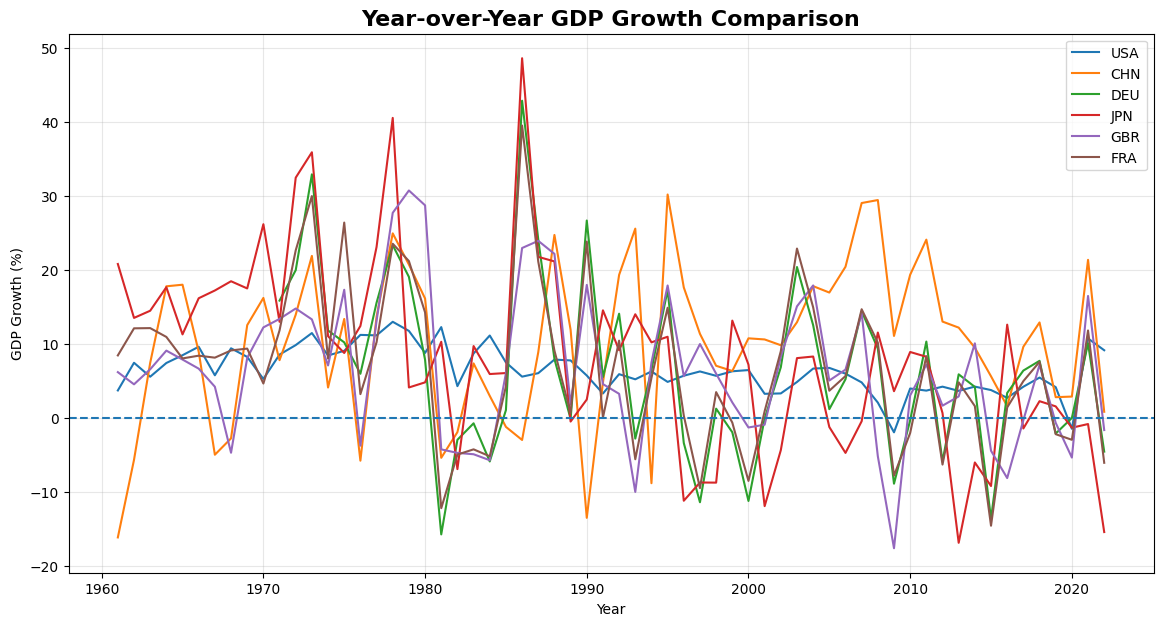

In [30]:
# Compare GDP growth for the selected countries
growth_comparison = gdp_df[
    gdp_df["Country Code"].isin(selected_countries)
]

plt.figure(figsize=(14, 7))

for country in selected_countries:
    country_data = growth_comparison[
        growth_comparison["Country Code"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["YoY Growth %"],
        label=country
    )

plt.axhline(0, linestyle="--")
plt.title("Year-over-Year GDP Growth Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [31]:
# Calculate total GDP growth between the first and last available years
start_year = int(gdp_df["Year"].min())
end_year = int(gdp_df["Year"].max())

start_gdp = (
    gdp_df[gdp_df["Year"] == start_year]
    .set_index("Country Code")["GDP"]
)

end_gdp = (
    gdp_df[gdp_df["Year"] == end_year]
    .set_index("Country Code")["GDP"]
)

growth_analysis = pd.DataFrame({
    "Start GDP": start_gdp,
    "End GDP": end_gdp
})

growth_analysis["Absolute Change"] = (
    growth_analysis["End GDP"] - growth_analysis["Start GDP"]
)

growth_analysis["Total Growth %"] = (
    growth_analysis["End GDP"] / growth_analysis["Start GDP"] - 1
) * 100

growth_analysis = growth_analysis.replace([np.inf, -np.inf], np.nan).dropna()

display(
    growth_analysis.sort_values("Total Growth %", ascending=False).head(10)
)

,Start GDP,End GDP,Absolute Change,Total Growth %
Country Code,,,,
BWA,3.041141e+07,2.035554e+10,2.032513e+10,66833.889340
SGP,7.047517e+08,4.667884e+11,4.660837e+11,66134.452019
KOR,3.958812e+09,1.673916e+12,1.669958e+12,42183.304165
CHN,5.971625e+10,1.796317e+13,1.790346e+13,29980.876958
IRL,1.939330e+09,5.331400e+11,5.312007e+11,27390.941386
HKG,1.320797e+09,3.598386e+11,3.585178e+11,27144.056307
TEA,8.091161e+10,2.116733e+13,2.108641e+13,26061.048741
EAP,8.101279e+10,2.119377e+13,2.111276e+13,26061.019005
MYS,1.916229e+09,4.070275e+11,4.051112e+11,21141.059934


In [32]:
# Calculate compound annual growth rate
number_of_years = end_year - start_year

growth_analysis["CAGR %"] = (
    (growth_analysis["End GDP"] / growth_analysis["Start GDP"])
    ** (1 / number_of_years) - 1
) * 100

display(
    growth_analysis.sort_values("CAGR %", ascending=False).head(10)
)

,Start GDP,End GDP,Absolute Change,Total Growth %,CAGR %
Country Code,,,,,
BWA,3.041141e+07,2.035554e+10,2.032513e+10,66833.889340,11.064416
SGP,7.047517e+08,4.667884e+11,4.660837e+11,66134.452019,11.045600
KOR,3.958812e+09,1.673916e+12,1.669958e+12,42183.304165,10.244660
CHN,5.971625e+10,1.796317e+13,1.790346e+13,29980.876958,9.640858
IRL,1.939330e+09,5.331400e+11,5.312007e+11,27390.941386,9.481759
HKG,1.320797e+09,3.598386e+11,3.585178e+11,27144.056307,9.465831
TEA,8.091161e+10,2.116733e+13,2.108641e+13,26061.048741,9.394236
EAP,8.101279e+10,2.119377e+13,2.111276e+13,26061.019005,9.394234
MYS,1.916229e+09,4.070275e+11,4.051112e+11,21141.059934,9.027260


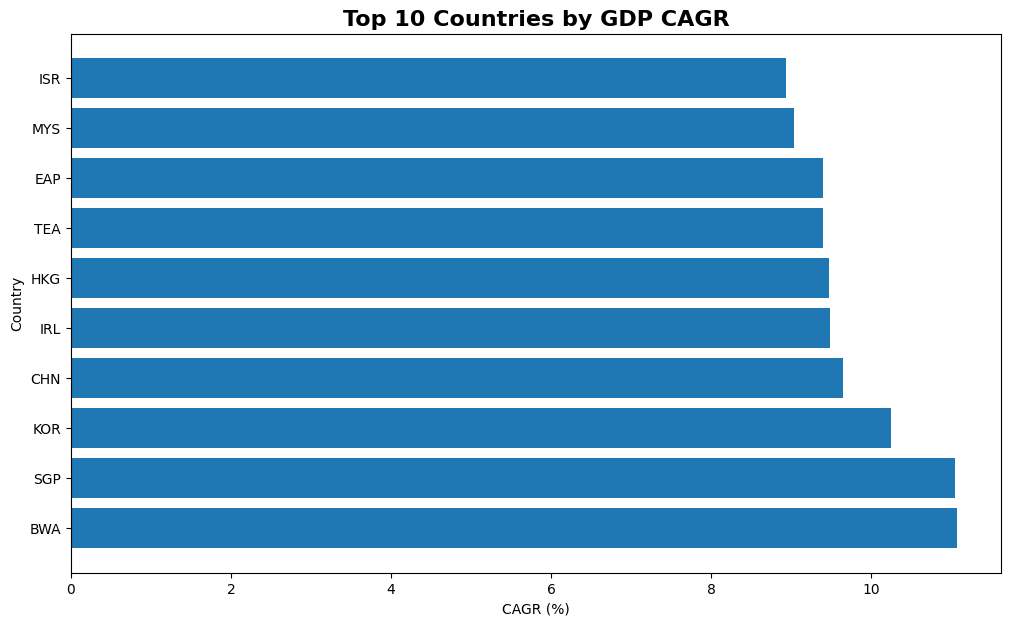

In [33]:
# Visualize the top countries by CAGR
top_cagr = (
    growth_analysis
    .sort_values("CAGR %", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_cagr["Country Code"],
    top_cagr["CAGR %"]
)

plt.title("Top 10 Countries by GDP CAGR", fontsize=16, fontweight="bold")
plt.xlabel("CAGR (%)")
plt.ylabel("Country")

plt.show()

In [34]:
# Calculate average annual GDP growth and growth volatility
average_growth = (
    gdp_df
    .groupby("Country Code")["YoY Growth %"]
    .mean()
    .reset_index(name="Average Growth %")
)

growth_volatility = (
    gdp_df
    .groupby("Country Code")["YoY Growth %"]
    .std()
    .reset_index(name="Growth Volatility")
)

growth_performance = (
    average_growth
    .merge(growth_volatility, on="Country Code", how="inner")
    .merge(
        growth_analysis[["CAGR %"]].reset_index(),
        on="Country Code",
        how="left"
    )
)

display(
    growth_performance.sort_values("CAGR %", ascending=False).head(15)
)

,Country Code,Average Growth %,Growth Volatility,CAGR %
33,BWA,11.871388,13.740222,11.064416
208,SGP,11.500047,10.134954,11.045600
126,KOR,11.441788,15.628829,10.244660
40,CHN,10.147507,10.498029,9.640858
111,IRL,9.901702,9.680520,9.481759
96,HKG,9.848107,9.369599,9.465831
230,TEA,9.755964,8.909559,9.394236
61,EAP,9.755962,8.909556,9.394234
169,MYS,9.661155,11.739212,9.027260
115,ISR,34.210342,236.848957,8.939278


## 9. Country Profiles & Historical Peaks

In [35]:
# Find the historical peak GDP for each country
valid_gdp = gdp_df.dropna(subset=["GDP"])

peak_index = valid_gdp.groupby("Country Code")["GDP"].idxmax()

peak_analysis = valid_gdp.loc[
    peak_index,
    ["Country Name", "Country Code", "Year", "GDP"]
].rename(
    columns={
        "Year": "Peak Year",
        "GDP": "Peak GDP"
    }
).reset_index(drop=True)

display(peak_analysis.head(10))

,Country Name,Country Code,Peak Year,Peak GDP
0,Aruba,ABW,2022,3.544708e+09
1,Africa Eastern and Southern,AFE,2022,1.185138e+12
2,Afghanistan,AFG,2014,2.049713e+10
3,Africa Western and Central,AFW,2014,8.945050e+11
4,Angola,AGO,2014,1.359668e+11
5,Albania,ALB,2022,1.891638e+10
6,Andorra,AND,2008,4.085780e+09
7,Arab World,ARB,2022,3.543340e+12
8,United Arab Emirates,ARE,2022,5.070640e+11
9,Argentina,ARG,2017,6.436284e+11


In [36]:
# Create a reusable country profile function
def country_profile(country_code):
    country_data = (
        gdp_df[gdp_df["Country Code"] == country_code]
        .dropna(subset=["GDP"])
        .sort_values("Year")
    )

    if country_data.empty:
        return None

    first_row = country_data.iloc[0]
    last_row = country_data.iloc[-1]
    peak_row = country_data.loc[country_data["GDP"].idxmax()]

    years = last_row["Year"] - first_row["Year"]

    if first_row["GDP"] > 0 and years > 0:
        cagr = (
            (last_row["GDP"] / first_row["GDP"]) ** (1 / years) - 1
        ) * 100
    else:
        cagr = np.nan

    return pd.Series({
        "Country Name": first_row["Country Name"],
        "Country Code": country_code,
        "First Year": first_row["Year"],
        "Latest Year": last_row["Year"],
        "First GDP": first_row["GDP"],
        "Latest GDP": last_row["GDP"],
        "CAGR %": cagr,
        "Peak GDP": peak_row["GDP"],
        "Peak Year": peak_row["Year"]
    })

In [37]:
# Generate a country profile for the United States
usa_profile = country_profile("USA")

display(usa_profile)

Country Name       United States
Country Code                 USA
First Year                  1960
Latest Year                 2022
First GDP         543300000000.0
Latest GDP      25439700000000.0
CAGR %                  6.400361
Peak GDP        25439700000000.0
Peak Year                   2022
dtype: object

In [38]:
# Generate profiles for all countries and economies
profiles = []

for country_code in gdp_df["Country Code"].dropna().unique():
    profile = country_profile(country_code)

    if profile is not None:
        profiles.append(profile)

country_profiles = pd.DataFrame(profiles)

display(country_profiles.head())

,Country Name,Country Code,First Year,Latest Year,First GDP,Latest GDP,CAGR %,Peak GDP,Peak Year
0,Aruba,ABW,1986,2022,4.055866e+08,3.544708e+09,6.206890,3.544708e+09,2022
1,Africa Eastern and Southern,AFE,1960,2022,1.847810e+10,1.185138e+12,6.941670,1.185138e+12,2022
2,Afghanistan,AFG,1960,2021,5.377778e+08,1.426650e+10,5.521166,2.049713e+10,2014
3,Africa Western and Central,AFW,1960,2022,1.041165e+10,8.753937e+11,7.409647,8.945050e+11,2014
4,Angola,AGO,1980,2022,5.934074e+09,1.067828e+11,7.123433,1.359668e+11,2014


## 10. Data Coverage & Global GDP Share

In [39]:
# Calculate data coverage for each country
coverage = (
    gdp_df
    .groupby(["Country Name", "Country Code"])["GDP"]
    .agg(
        Available_Years="count",
        Missing_Years=lambda values: values.isna().sum()
    )
    .reset_index()
)

coverage["Coverage %"] = (
    coverage["Available_Years"] / len(year_columns)
) * 100

display(
    coverage.sort_values("Coverage %").head(20)
)

,Country Name,Country Code,Available_Years,Missing_Years,Coverage %
90,Gibraltar,GIB,0,63,0.000000
183,Not classified,INX,0,63,0.000000
125,"Korea, Dem. People's Rep.",PRK,0,63,0.000000
30,British Virgin Islands,VGB,0,63,0.000000
227,St. Martin (French part),MAF,4,59,6.349206
222,South Sudan,SSD,8,55,12.698413
213,Sint Maarten (Dutch part),SXM,12,51,19.047619
55,Curacao,CUW,12,51,19.047619
171,Nauru,NRU,13,50,20.634921
127,Kosovo,XKX,15,48,23.809524


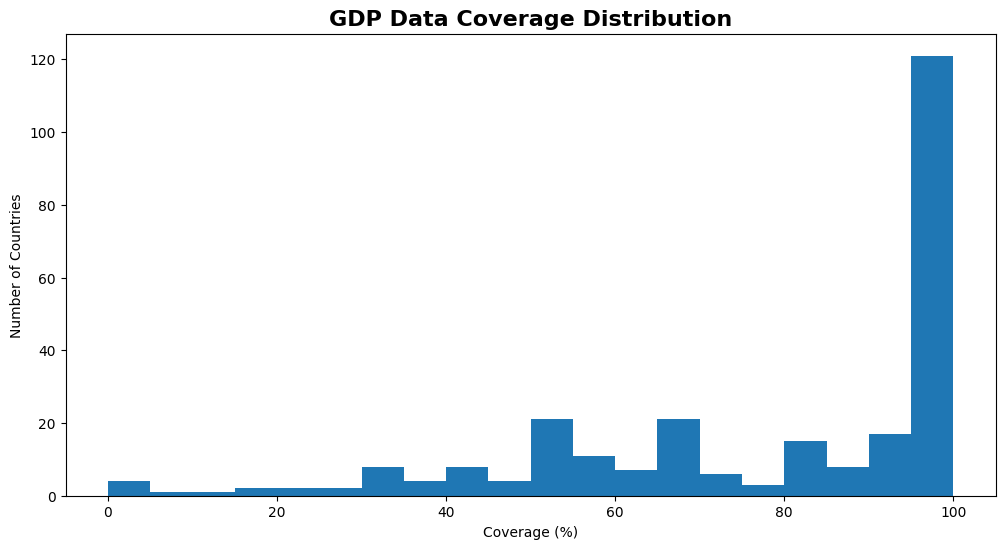

In [40]:
# Visualize the distribution of data coverage
plt.figure(figsize=(12, 6))

plt.hist(
    coverage["Coverage %"],
    bins=20
)

plt.title("GDP Data Coverage Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Coverage (%)")
plt.ylabel("Number of Countries")

plt.show()

In [41]:
# Calculate each country's share of global GDP in the latest year
latest_global_gdp = global_gdp.loc[
    global_gdp["Year"] == latest_year,
    "GDP"
].iloc[0]

latest_share = latest_gdp.copy()
latest_share["Global GDP Share %"] = (
    latest_share["GDP"] / latest_global_gdp * 100
)

latest_share = latest_share.sort_values(
    "Global GDP Share %",
    ascending=False
)

display(
    latest_share[
        ["Country Name", "Country Code", "GDP", "Global GDP Share %"]
    ].head(10)
)

,Country Name,Country Code,GDP,Global GDP Share %
16751,World,WLD,1.013257e+14,11.984812
16587,High income,HIC,6.166747e+13,7.294034
16673,OECD members,OED,5.978785e+13,7.071713
16690,Post-demographic dividend,PST,5.666168e+13,6.701949
16595,IDA & IBRD total,IBT,4.057396e+13,4.799092
16632,Low & middle income,LMY,3.930979e+13,4.649566
16648,Middle income,MIC,3.878098e+13,4.587018
16594,IBRD only,IBD,3.775237e+13,4.465354
16555,East Asia & Pacific,EAS,3.068824e+13,3.629807
16741,Upper middle income,UMC,3.060946e+13,3.620490


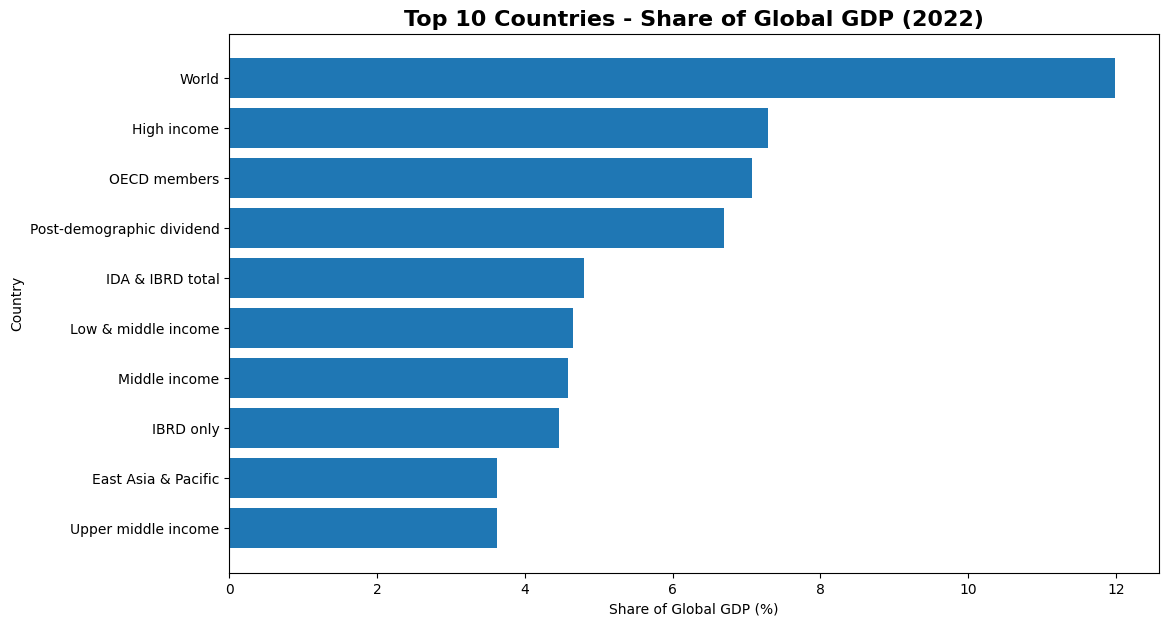

In [42]:
# Visualize the top countries by global GDP share
top_10_share = latest_share.head(10).sort_values("Global GDP Share %")

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_share["Country Name"],
    top_10_share["Global GDP Share %"]
)

plt.title(
    f"Top 10 Countries - Share of Global GDP ({latest_year})",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Share of Global GDP (%)")
plt.ylabel("Country")

plt.show()

## 11. Correlation Analysis

In [43]:
# Reshape selected countries into separate GDP columns
pivot_gdp = comparison_df.pivot(
    index="Year",
    columns="Country Code",
    values="GDP"
)

# Calculate the correlation matrix
correlation_matrix = pivot_gdp.corr()

display(correlation_matrix)

Country Code,CHN,DEU,FRA,GBR,JPN,USA
Country Code,,,,,,
CHN,1.000000,0.811345,0.789349,0.794214,0.586854,0.901136
DEU,0.811345,1.000000,0.993186,0.976781,0.908065,0.960966
FRA,0.789349,0.993186,1.000000,0.987813,0.925168,0.961254
GBR,0.794214,0.976781,0.987813,1.000000,0.902137,0.969944
JPN,0.586854,0.908065,0.925168,0.902137,1.000000,0.853404
USA,0.901136,0.960966,0.961254,0.969944,0.853404,1.000000


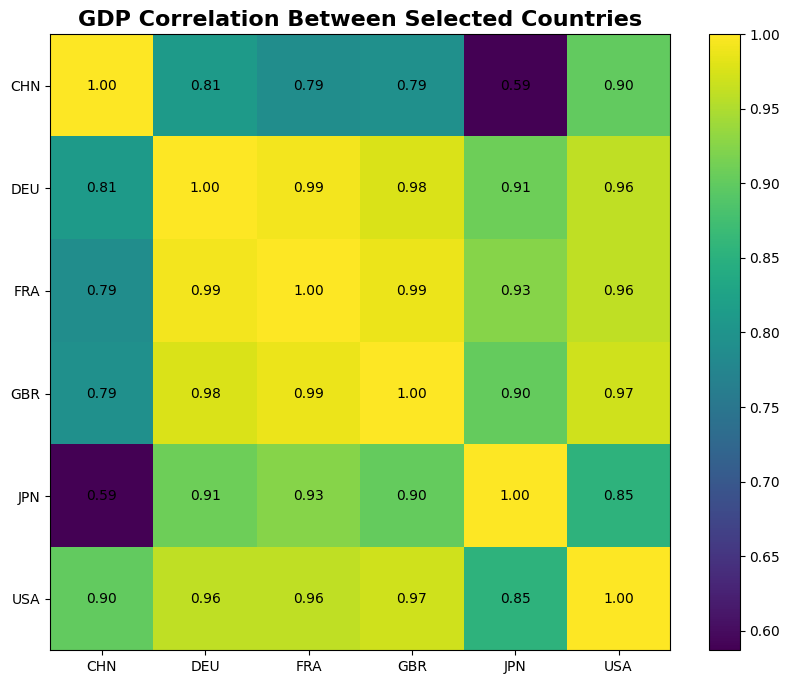

In [44]:
# Visualize GDP correlations between selected countries
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("GDP Correlation Between Selected Countries", fontsize=16, fontweight="bold")
plt.show()

## 12. Period Analysis

In [45]:
# Define a focused period for comparative analysis
period_start = 2000
period_end = latest_year

period_data = gdp_df[
    (gdp_df["Year"] >= period_start)
    & (gdp_df["Year"] <= period_end)
]

print(f"Analysis period: {period_start} - {period_end}")

Analysis period: 2000 - 2022


In [46]:
# Calculate GDP growth between the beginning and end of the selected period
period_start_gdp = (
    period_data[period_data["Year"] == period_start]
    .set_index("Country Code")["GDP"]
)

period_end_gdp = (
    period_data[period_data["Year"] == period_end]
    .set_index("Country Code")["GDP"]
)

period_growth = pd.DataFrame({
    "Start GDP": period_start_gdp,
    "End GDP": period_end_gdp
})

period_growth["Growth %"] = (
    period_growth["End GDP"] / period_growth["Start GDP"] - 1
) * 100

period_growth = period_growth.replace([np.inf, -np.inf], np.nan).dropna()

display(
    period_growth.sort_values("Growth %", ascending=False).head(10)
)

,Start GDP,End GDP,Growth %
Country Code,,,
CUB,3.056540e+10,6.334423e+11,1972.416196
GUY,7.126679e+08,1.471839e+10,1965.252070
TKM,2.904663e+09,5.654286e+10,1846.623450
ETH,8.242350e+09,1.267835e+11,1438.195751
MNG,1.136896e+09,1.714647e+10,1408.182786
AZE,5.272616e+09,7.872106e+10,1393.017185
CHN,1.211332e+12,1.796317e+13,1382.927607
GHA,4.982851e+09,7.376605e+10,1380.398620
QAT,1.775989e+10,2.362583e+11,1230.291468


## 13. Final Analytical Summary

In [47]:
# Calculate the main project KPIs
total_countries = gdp_df["Country Code"].nunique()
total_years = gdp_df["Year"].nunique()
total_observations = len(gdp_df)
available_gdp = gdp_df["GDP"].notna().sum()
missing_gdp = gdp_df["GDP"].isna().sum()
data_coverage = available_gdp / total_observations * 100

print("Global GDP Explorer")
print("-" * 30)
print("Countries:", total_countries)
print("Years:", f"{start_year} - {end_year}")
print("Observations:", f"{total_observations:,}")
print("Available GDP Values:", f"{available_gdp:,}")
print("Missing GDP Values:", f"{missing_gdp:,}")
print(f"Overall Data Coverage: {data_coverage:.2f}%")
print(f"Latest Year: {latest_year}")
print(f"Latest Global GDP: ${latest_global_gdp / 1e12:,.2f} Trillion")

Global GDP Explorer
------------------------------
Countries: 266
Years: 1960 - 2022
Observations: 16,758
Available GDP Values: 13,200
Missing GDP Values: 3,558
Overall Data Coverage: 78.77%
Latest Year: 2022
Latest Global GDP: $845.45 Trillion


In [48]:
# Create a final country-level analytical dataset
final_summary = (
    latest_gdp[
        ["Country Name", "Country Code", "GDP"]
    ]
    .merge(
        growth_analysis[["Total Growth %", "CAGR %"]].reset_index(),
        on="Country Code",
        how="left"
    )
    .merge(
        average_growth,
        on="Country Code",
        how="left"
    )
    .merge(
        coverage[["Country Code", "Available_Years", "Missing_Years", "Coverage %"]],
        on="Country Code",
        how="left"
    )
    .sort_values("GDP", ascending=False)
)

display(final_summary.head(20))

,Country Name,Country Code,GDP,Total Growth %,CAGR %,Average Growth %,Available_Years,Missing_Years,Coverage %
0,World,WLD,1.013257e+14,7236.404589,7.173753,7.328911,63,0,100.000000
1,High income,HIC,6.166747e+13,5667.638275,6.758680,6.921964,63,0,100.000000
2,OECD members,OED,5.978785e+13,5469.463892,6.698492,6.859167,63,0,100.000000
3,Post-demographic dividend,PST,5.666168e+13,5313.148707,6.649511,6.812046,63,0,100.000000
4,IDA & IBRD total,IBT,4.057396e+13,11194.624546,7.922211,8.207976,63,0,100.000000
5,Low & middle income,LMY,3.930979e+13,11641.679049,7.989802,8.276629,63,0,100.000000
6,Middle income,MIC,3.878098e+13,11828.730477,8.017334,8.312289,63,0,100.000000
7,IBRD only,IBD,3.775237e+13,11610.934666,7.985236,8.277273,63,0,100.000000
8,East Asia & Pacific,EAS,3.068824e+13,19758.936048,8.909009,9.237165,63,0,100.000000
9,Upper middle income,UMC,3.060946e+13,12862.619628,8.162244,8.526316,63,0,100.000000


## 14. Export Analytical Outputs

In [49]:
# Create the output directory if it does not exist
output_dir = Path("../data")
output_dir.mkdir(parents=True, exist_ok=True)

# Save the cleaned long-format dataset
long_path = output_dir / "gdp_data_long.csv"
gdp_df.to_csv(long_path, index=False)

# Save the country-level summary dataset
summary_path = output_dir / "gdp_country_summary.csv"
final_summary.to_csv(summary_path, index=False)

print("Saved:")
print(long_path)
print(summary_path)

Saved:
../data/gdp_data_long.csv
../data/gdp_country_summary.csv


## 15. Key Findings

In [50]:
# Identify the largest economy in the latest available year
largest_economy = latest_ranking.iloc[0]

# Identify the country with the highest CAGR
highest_cagr_row = (
    growth_analysis
    .sort_values("CAGR %", ascending=False)
    .iloc[0]
)

print("Key Findings")
print("-" * 30)
print(
    f"Largest economy in {latest_year}: "
    f"{largest_economy['Country Name']} ({largest_economy['Country Code']})"
)
print(
    f"Latest GDP: ${largest_economy['GDP'] / 1e12:,.2f} Trillion"
)
print(
    f"Highest CAGR in the full period: "
    f"{highest_cagr_row.name} ({highest_cagr_row['CAGR %']:.2f}%)"
)
print(
    f"Overall GDP data coverage: {data_coverage:.2f}%"
)

Key Findings
------------------------------
Largest economy in 2022: World (WLD)
Latest GDP: $101.33 Trillion
Highest CAGR in the full period: BWA (11.06%)
Overall GDP data coverage: 78.77%


## 16. Business Questions Addressed

In [51]:
# Define the main analytical questions answered by the project
business_questions = [
    "How has global GDP changed over time?",
    "Which economies have the largest GDP in the latest available year?",
    "How does GDP growth differ between countries?",
    "Which countries have the highest long-term GDP growth based on CAGR?",
    "What share of global GDP is represented by the largest economies?",
    "How complete is the available GDP data?"
]

for number, question in enumerate(business_questions, start=1):
    print(f"{number}. {question}")

1. How has global GDP changed over time?
2. Which economies have the largest GDP in the latest available year?
3. How does GDP growth differ between countries?
4. Which countries have the highest long-term GDP growth based on CAGR?
5. What share of global GDP is represented by the largest economies?
6. How complete is the available GDP data?


## 17. Analytical Limitations

In [52]:
# Document the main limitations of the analysis
limitations = [
    "GDP observations are missing for some countries and years.",
    "Comparisons across periods can be affected by incomplete data coverage.",
    "GDP alone does not fully describe the economic condition or living standards of a country.",
    "The analysis identifies trends and relationships but does not establish causation.",
    "Country codes are used as stable identifiers, while country names are retained for presentation."
]

for limitation in limitations:
    print(f"- {limitation}")

- GDP observations are missing for some countries and years.
- Comparisons across periods can be affected by incomplete data coverage.
- GDP alone does not fully describe the economic condition or living standards of a country.
- The analysis identifies trends and relationships but does not establish causation.
- Country codes are used as stable identifiers, while country names are retained for presentation.


## 18. Conclusion

In [53]:
# Summarize the completed analytical workflow
print("""
The Global GDP Explorer analyzes GDP data across countries and years
through a complete data analytics workflow.

The notebook covers:

- Data loading and understanding
- Data quality and missing-value assessment
- Data transformation
- Exploratory data analysis
- Global GDP trends
- Country comparison
- Year-over-year growth
- Total growth and CAGR
- Historical GDP peaks
- Country profiles
- GDP rankings
- Global GDP share
- Correlation analysis
- Data coverage
- Period-based analysis
- Analytical outputs for the Streamlit dashboard

The cleaned datasets and analytical results produced here form the
analytical foundation of the interactive Global GDP Explorer application.
""")


The Global GDP Explorer analyzes GDP data across countries and years
through a complete data analytics workflow.

The notebook covers:

- Data loading and understanding
- Data quality and missing-value assessment
- Data transformation
- Exploratory data analysis
- Global GDP trends
- Country comparison
- Year-over-year growth
- Total growth and CAGR
- Historical GDP peaks
- Country profiles
- GDP rankings
- Global GDP share
- Correlation analysis
- Data coverage
- Period-based analysis
- Analytical outputs for the Streamlit dashboard

The cleaned datasets and analytical results produced here form the
analytical foundation of the interactive Global GDP Explorer application.

